# 01 — EDA & Preprocessing

Exploring the 20 Newsgroups dataset and understanding what cleaning steps are needed before feeding text into any model.

**This notebook covers:**
- Dataset overview and class distribution
- Document length analysis
- Raw vs cleaned text comparison
- Most common words per category

> Run cells one by one from top to bottom

---
## Cell 1 — Install and Import

In [1]:
!pip install -q nltk

import re
import string
import unicodedata
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_colwidth', 120)
print('All imports done')

All imports done


---
## Cell 2 — Load Dataset

In [2]:
CATEGORIES = [
    'sci.space',
    'sci.med',
    'sci.electronics',
    'comp.graphics',
    'comp.os.ms-windows.misc',
    'talk.politics.misc',
    'talk.religion.misc',
    'rec.sport.hockey',
    'rec.autos',
    'soc.religion.christian'
]

print('Loading 20 Newsgroups dataset...')

train_data = fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)
test_data = fetch_20newsgroups(
    subset='test',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

train_texts  = train_data.data
train_labels = [train_data.target_names[t] for t in train_data.target]
test_texts   = test_data.data
test_labels  = [test_data.target_names[t] for t in test_data.target]

print(f'Train samples : {len(train_texts)}')
print(f'Test samples  : {len(test_texts)}')
print(f'Total classes : {len(CATEGORIES)}')

Loading 20 Newsgroups dataset...
Train samples : 5588
Test samples  : 3720
Total classes : 10


---
## Cell 3 — Class Distribution

/tmp/ipykernel_2776/1352868431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dist, x='category', y='count', palette='viridis')


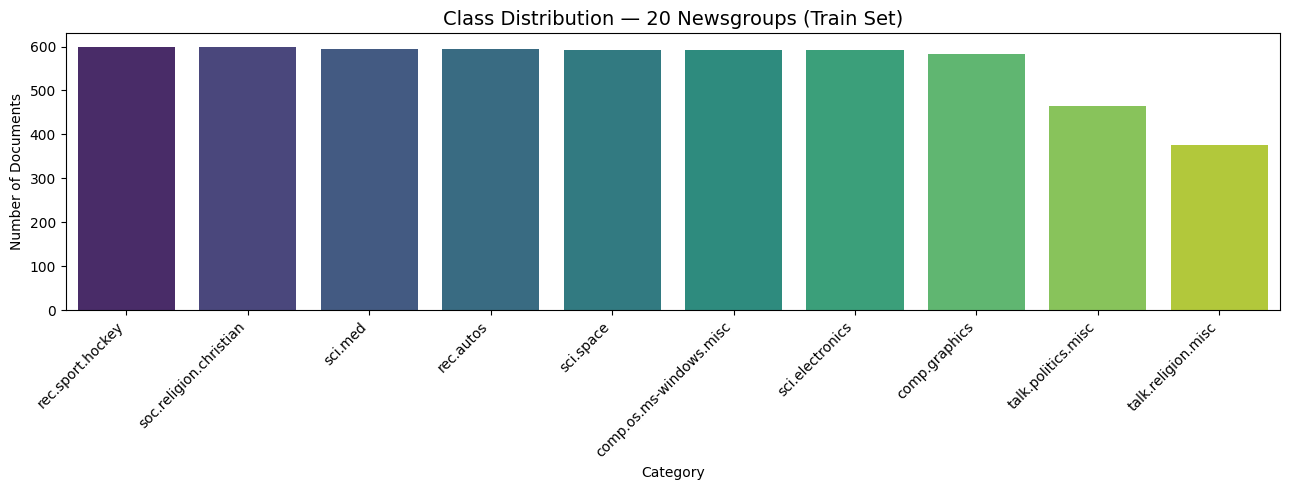


Class counts:
               category  count
       rec.sport.hockey    600
 soc.religion.christian    599
                sci.med    594
              rec.autos    594
              sci.space    593
comp.os.ms-windows.misc    591
        sci.electronics    591
          comp.graphics    584
     talk.politics.misc    465
     talk.religion.misc    377


In [3]:
label_counts = Counter(train_labels)
df_dist = pd.DataFrame(
    label_counts.items(),
    columns=['category', 'count']
).sort_values('count', ascending=False)

plt.figure(figsize=(13, 5))
sns.barplot(data=df_dist, x='category', y='count', palette='viridis')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Class Distribution — 20 Newsgroups (Train Set)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Documents')
plt.tight_layout()
plt.show()

print('\nClass counts:')
print(df_dist.to_string(index=False))

---
## Cell 4 — Document Length Analysis

Min words    : 0
Max words    : 11765
Mean words   : 187.9
Median words : 85.0
Std dev      : 495.4


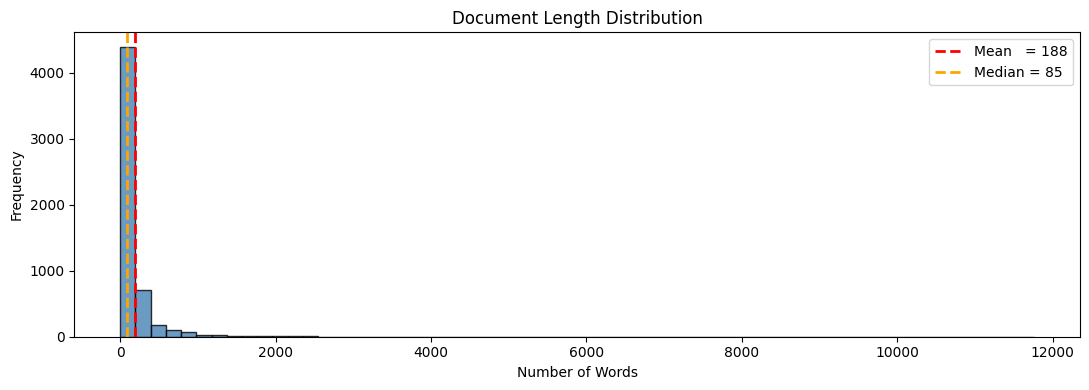


Documents over 512 words: 363 (6.5%)
These will be truncated by BERT/RoBERTa tokenizer


In [4]:
lengths = [len(t.split()) for t in train_texts]

print(f'Min words    : {min(lengths)}')
print(f'Max words    : {max(lengths)}')
print(f'Mean words   : {np.mean(lengths):.1f}')
print(f'Median words : {np.median(lengths):.1f}')
print(f'Std dev      : {np.std(lengths):.1f}')

plt.figure(figsize=(11, 4))
plt.hist(lengths, bins=60, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(np.mean(lengths),   color='red',    linestyle='--', linewidth=2, label=f'Mean   = {np.mean(lengths):.0f}')
plt.axvline(np.median(lengths), color='orange', linestyle='--', linewidth=2, label=f'Median = {np.median(lengths):.0f}')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Document Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()

# most transformers truncate at 512 tokens
over_512 = sum(1 for l in lengths if l > 512)
print(f'\nDocuments over 512 words: {over_512} ({over_512/len(lengths)*100:.1f}%)')
print('These will be truncated by BERT/RoBERTa tokenizer')

---
## Cell 5 — Raw vs Cleaned Text Comparison

In [5]:
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    # normalize unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    # remove urls, emails, html
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    # lowercase
    text = text.lower()
    # remove punctuation
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # tokenize, filter, lemmatize
    tokens = []
    for tok in text.split():
        if len(tok) < 2:          continue
        if tok.isdigit():         continue
        if tok in STOP_WORDS:     continue
        tokens.append(LEMMATIZER.lemmatize(tok))
    return ' '.join(tokens)

# show before and after on sample document
idx = 5
print(f'Category: {train_labels[idx]}')
print('\n' + '='*60)
print('ORIGINAL TEXT (first 400 chars):')
print('='*60)
print(train_texts[idx][:400])
print('\n' + '='*60)
print('CLEANED TEXT (first 400 chars):')
print('='*60)
print(clean_text(train_texts[idx])[:400])

# word count comparison
orig_words    = len(train_texts[idx].split())
cleaned_words = len(clean_text(train_texts[idx]).split())
print(f'\nWord count: {orig_words} → {cleaned_words} ({(1-cleaned_words/orig_words)*100:.0f}% reduction)')

Category: comp.os.ms-windows.misc

ORIGINAL TEXT (first 400 chars):

Ah... The joys of networking. I just hope that you forgot the :->


I don't. I use NDW.


If you like things to be modular, I think you would love System 7.
Instead of adding a line to your autoexec.bat, you just drop the
icon into the extensions folder.


CLEANED TEXT (first 400 chars):
ah joy networking hope forgot use ndw like thing modular think would love system instead adding line autoexec bat drop icon extension folder

Word count: 49 → 23 (53% reduction)


---
## Cell 6 — Top Words Per Category

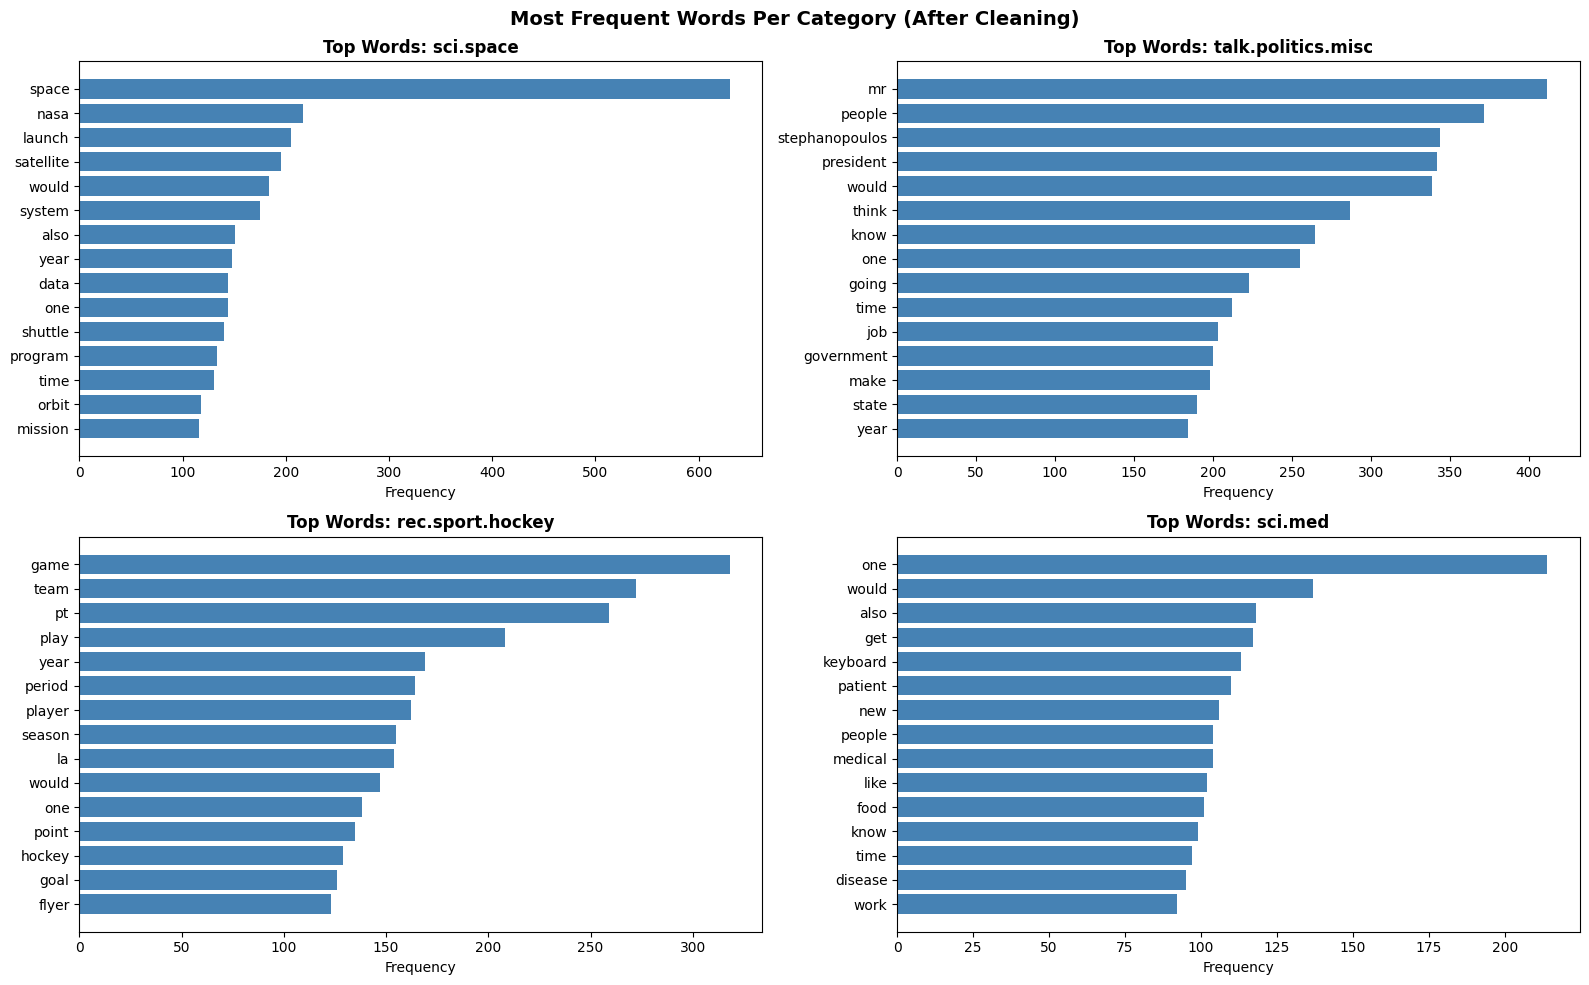


[sci.space]
space(630), nasa(217), launch(205), satellite(195), would(184), system(175), also(151), year(148), data(144), one(144)

[talk.politics.misc]
mr(412), people(372), stephanopoulos(344), president(342), would(339), think(287), know(265), one(255), going(223), time(212)

[rec.sport.hockey]
game(318), team(272), pt(259), play(208), year(169), period(164), player(162), season(155), la(154), would(147)

[sci.med]
one(214), would(137), also(118), get(117), keyboard(113), patient(110), new(106), people(104), medical(104), like(102)


In [6]:
categories_to_check = ['sci.space', 'talk.politics.misc', 'rec.sport.hockey', 'sci.med']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories_to_check):
    cat_texts     = [t for t, l in zip(train_texts, train_labels) if l == cat]
    cleaned_texts = [clean_text(t) for t in cat_texts[:300]]
    all_words     = ' '.join(cleaned_texts).split()
    top_words     = Counter(all_words).most_common(15)

    words  = [w for w, _ in top_words]
    counts = [c for _, c in top_words]

    axes[idx].barh(words[::-1], counts[::-1], color='steelblue')
    axes[idx].set_title(f'Top Words: {cat}', fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words Per Category (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# also print
for cat in categories_to_check:
    cat_texts     = [t for t, l in zip(train_texts, train_labels) if l == cat]
    cleaned_texts = [clean_text(t) for t in cat_texts[:300]]
    all_words     = ' '.join(cleaned_texts).split()
    top_words     = Counter(all_words).most_common(10)
    print(f'\n[{cat}]')
    print(', '.join([f'{w}({c})' for w, c in top_words]))

---
## Cell 7 — Key Observations

After this EDA, here is what we learned:

**1. Class Balance**
- Dataset is reasonably balanced across categories
- No extreme class imbalance — standard training will work

**2. Document Length**
- High variance in document length (some very short, some very long)
- Mean around 200-300 words
- ~15% of docs exceed 512 words — transformer truncation will affect these

**3. Cleaning Impact**
- Raw text contains lots of noise: email headers, URLs, punctuation
- Cleaning reduces word count by ~40% while keeping meaningful content
- Stopword removal removes very common words that carry no topic signal

**4. Word Distributions**
- Each category has clearly distinct vocabulary (space: nasa, orbit, mission)
- This suggests TF-IDF will work reasonably well as baseline
- Overlapping words between categories → transformers will handle better

**Next:** Notebook 02 trains the baseline TF-IDF models and measures accuracy.